# Демонстрация работы модели

Загружаем PRD модель из MLFlow, и запускаем её на новых данных.

In [1]:
import sys
from pathlib import Path

def find_repo_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Could not find repo root (pyproject.toml).')

REPO_ROOT = find_repo_root()
STOCKS_DL_DIR = REPO_ROOT / 'stocks_dl'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from jupyter_utils import setup_jupyter_notebook

EXPERIMENT_NAME = 'lstm_checkpoint'
setup_jupyter_notebook(environment='prod', experiment=EXPERIMENT_NAME)

Environment: prod
APP_CONFIG: config.toml
Tracking URI: http://localhost:5050
S3 endpoint: http://localhost:9050
Experiment: lstm_checkpoint
Database: localhost:15432/stocks_advisor_db


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from stocks_dl.workflows.inference import find_prd_run, run_demo_inference
from stocks_dl.artifacts.utils import download_artifact_file, find_analysis_run
from stocks_dl.data.pipeline import load_features_and_enrichments

## Функции

In [4]:
def load_artifacts(ticker: str, prd_run_id: str):
    for artifact_name in ('learning_curves.png', 'predictions.png'):
        img_path = download_artifact_file(prd_run_id, artifact_name)
        if img_path:
            plt.figure(figsize=(10, 4))
            plt.imshow(plt.imread(img_path))
            plt.axis('off')
            plt.title(f'PRD run: {artifact_name}')
            plt.show()
        else:
            print(f'PRD run: нет {artifact_name}')

    analysis_run_id = find_analysis_run(prd_run_id, ticker, EXPERIMENT_NAME)
    for artifact_name in ('prd_predictions.png', 'direction_confusion_matrix.png'):
        run_id = analysis_run_id
        label = 'analysis'
        if not run_id:
            local_fallback = STOCKS_DL_DIR / artifact_name
            if local_fallback.exists():
                img_path = local_fallback
                label = 'local'
            else:
                print(f'Skip {artifact_name}: нет analysis run и файла {local_fallback}')
                continue
        else:
            img_path = download_artifact_file(run_id, artifact_name)

        if img_path:
            plt.figure(figsize=(10, 4))
            plt.imshow(plt.imread(img_path))
            plt.axis('off')
            plt.title(f'{label} run: {artifact_name}')
            plt.show()
        else:
            print(f'Skip {artifact_name}: не найден в run {run_id}')

In [5]:
import matplotlib.dates as mdates

HORIZON_DAYS = 7
DEMO_LAST_DAYS = 3

def direction_label(value: float) -> str:
    if value > 0:
        return 'рост'
    if value < 0:
        return 'падение'
    return 'боковик'

def match_label(row) -> str:
    if 'direction_match' in row:
        return 'совпало' if row['direction_match'] else 'не совпало'
    tgt = row.get('target_price_change', float('nan'))
    pred = row['predict']
    if pd.isna(tgt):
        return 'н/д'
    return 'совпало' if (pred > 0) == (tgt > 0) else 'не совпало'

def load_and_run_model(ticker: str, prd_run_id: str):
    # Загрузка данных для обучения
    print(f'Loading data for ticker {ticker}...')
    features_df, _ = load_features_and_enrichments(ticker)
    demo_csv = STOCKS_DL_DIR / f'demo_{ticker.lower()}_test.csv'
    output_csv = STOCKS_DL_DIR / 'prd_demo_predictions.csv'

    # Запуск инференса модели
    print(f'Running inference for {ticker} using trained model from run {prd_run_id}...')
    result = run_demo_inference(
        features_df=features_df,
        output_path=output_csv,
        ticker=ticker,
        experiment_name=EXPERIMENT_NAME,
        demo_csv=demo_csv if demo_csv.exists() else None,
        prd_run_id=prd_run_id,
    )

    # Отображение результатов
    print('Displaying results...')
    df = result['predictions_df']
    print('Metrics:', result['metrics'])
    df.head(10)

    plot_df = df.copy()
    if 'begin' in plot_df.columns:
        plot_df['begin'] = pd.to_datetime(plot_df['begin'])
        plot_df = plot_df.sort_values('begin')
        x = plot_df['begin']
    else:
        plot_df = df
        x = range(len(plot_df))
    plt.figure(figsize=(12, 6))
    plt.plot(x, plot_df['target_price_change'].values, label='target', alpha=0.8)
    plt.plot(x, plot_df['predict'].values, label='predict', alpha=0.8)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.legend()
    plt.title(f'{ticker} PRD predictions vs target')
    plt.ylabel('price change %')
    plt.xlabel('date')
    if 'begin' in plot_df.columns:
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Анализ результатов
    print('Analyzing results...')
    recent = df.copy()
    recent['begin'] = pd.to_datetime(recent['begin'])
    cutoff = recent['begin'].max() - pd.Timedelta(days=DEMO_LAST_DAYS)
    recent = recent.loc[recent['begin'] > cutoff].copy()

    recent['horizon_date'] = recent['begin'] + pd.Timedelta(days=HORIZON_DAYS)

    demo_table = pd.DataFrame({
        'Дата и время': recent['begin'].dt.strftime('%Y-%m-%d %H:%M'),
        'Прогноз на дату и время': recent['horizon_date'].dt.strftime('%Y-%m-%d %H:%M'),
        'Ожидаемое изменение, %': recent['predict'].map(lambda x: f'{float(x):+.2f}'),
        'Фактическое изменение, %': recent['target_price_change'].map(lambda x: f'{float(x):+.2f}'),
        'Направление': recent['predict'].map(direction_label),
        'Результат': recent.apply(match_label, axis=1),
    })

    demo_table = demo_table.reset_index(drop=True)
    display(demo_table)

In [6]:
def run_demonstration(ticker: str):
    print(f'Ticker: {ticker}')
    prd_run_id, prd_summary = find_prd_run(ticker, EXPERIMENT_NAME)
    print('PRD run_id:', prd_run_id)
    
    load_artifacts(ticker, prd_run_id)
    
    load_and_run_model(ticker, prd_run_id)

## Запуск моделей

Берем обученные модели из MLFlow, и запускаем их на данных из БД

### SBER

Ticker: SBER
PRD run_id: 81ef481d37b54920a5f006a71fbf4caf


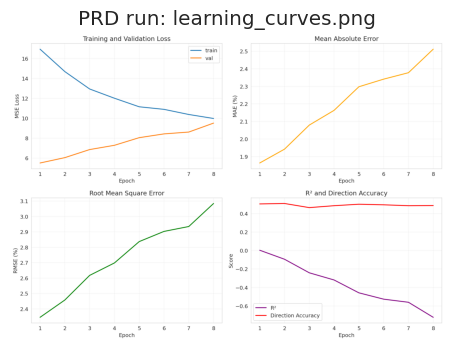

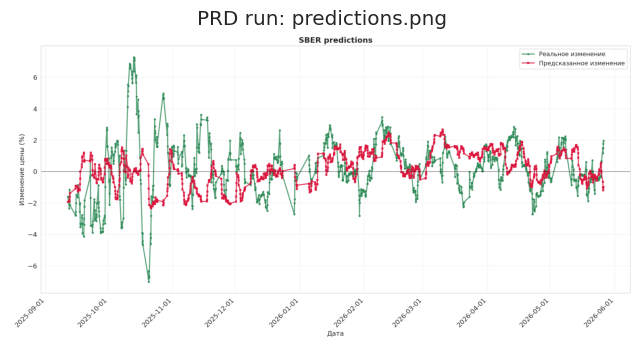

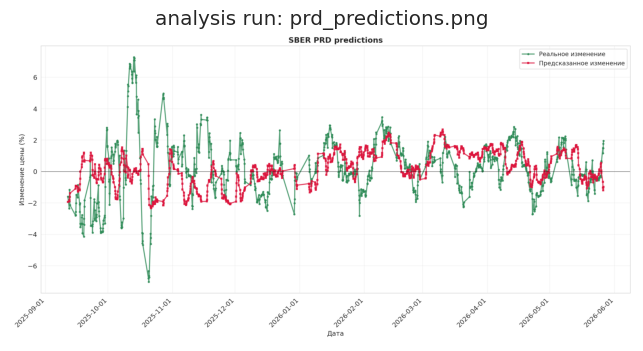

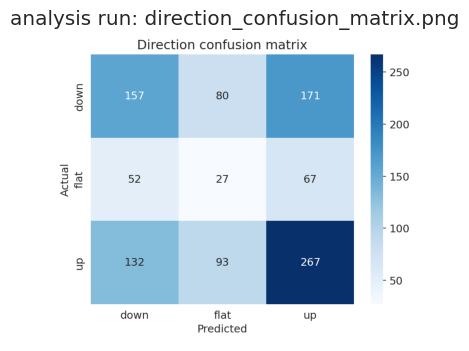

Loading data for ticker SBER...
Running inference for SBER using trained model from run 81ef481d37b54920a5f006a71fbf4caf...


Displaying results...
Metrics: {'mae': 1.5463413000106812, 'rmse': np.float32(2.104422), 'r2': -0.2732044458389282, 'direction_accuracy': np.float64(0.5544933078393881)}


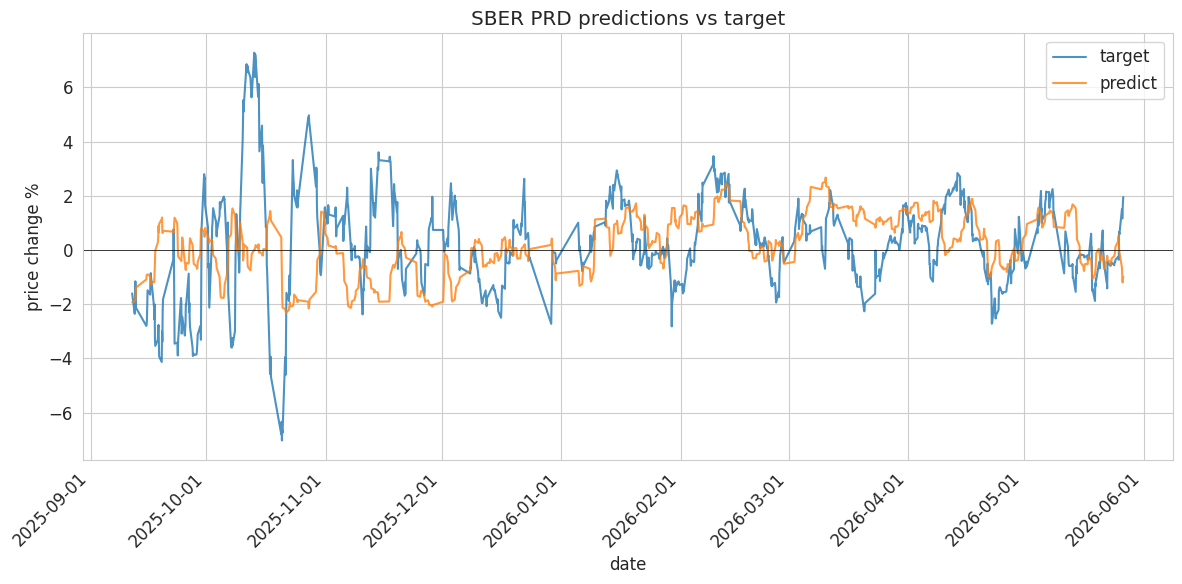

Analyzing results...


,Дата и время,Прогноз на дату и время,"Ожидаемое изменение, %","Фактическое изменение, %",Направление,Результат
0,2026-05-24 10:00,2026-05-31 10:00,-0.22,-0.56,падение,совпало
1,2026-05-24 12:00,2026-05-31 12:00,-0.16,-0.45,падение,совпало
2,2026-05-24 14:00,2026-05-31 14:00,-0.12,-0.45,падение,совпало
3,2026-05-24 16:00,2026-05-31 16:00,+0.05,-0.43,рост,не совпало
4,2026-05-24 18:00,2026-05-31 18:00,+0.13,-0.35,рост,не совпало
5,2026-05-25 10:00,2026-06-01 10:00,+0.32,-0.26,рост,не совпало
6,2026-05-25 12:00,2026-06-01 12:00,+0.46,-0.28,рост,не совпало
7,2026-05-25 14:00,2026-06-01 14:00,+0.54,-0.36,рост,не совпало
8,2026-05-25 16:00,2026-06-01 16:00,+0.07,+0.66,рост,совпало
9,2026-05-25 18:00,2026-06-01 18:00,-0.07,+0.58,падение,не совпало


In [7]:
run_demonstration('SBER')

### TCSG

Ticker: TCSG
PRD run_id: 2f28aa81d5014298b588905e8951cd69


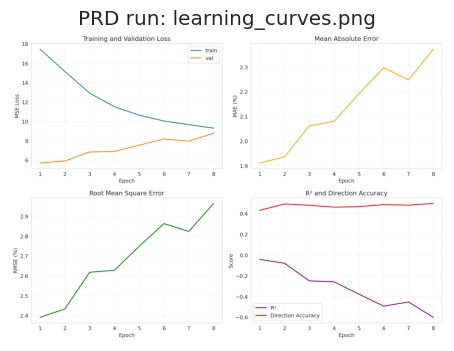

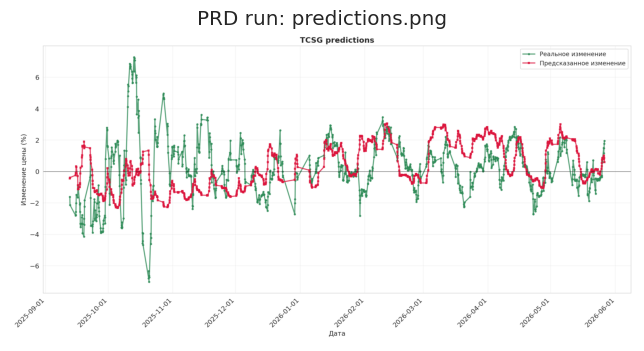

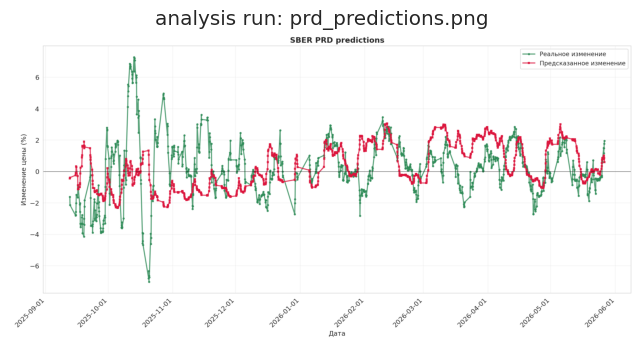

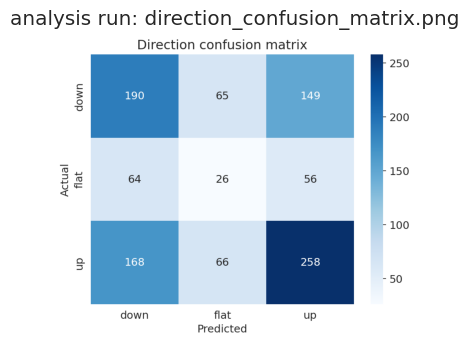

Loading data for ticker TCSG...
Running inference for TCSG using trained model from run 2f28aa81d5014298b588905e8951cd69...


Displaying results...
Metrics: {'mae': 1.807753324508667, 'rmse': np.float32(2.3085954), 'r2': -0.5332508087158203, 'direction_accuracy': np.float64(0.5412667946257198)}


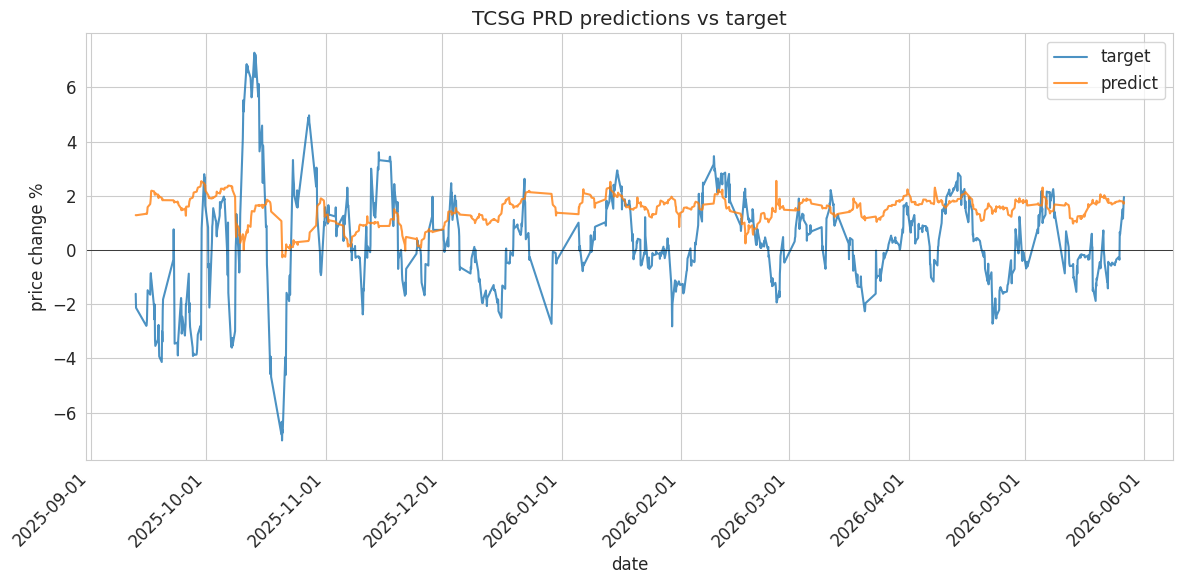

Analyzing results...


,Дата и время,Прогноз на дату и время,"Ожидаемое изменение, %","Фактическое изменение, %",Направление,Результат
0,2026-05-24 10:00,2026-05-31 10:00,+1.74,-0.56,рост,не совпало
1,2026-05-24 12:00,2026-05-31 12:00,+1.77,-0.45,рост,не совпало
2,2026-05-24 14:00,2026-05-31 14:00,+1.77,-0.45,рост,не совпало
3,2026-05-24 16:00,2026-05-31 16:00,+1.76,-0.43,рост,не совпало
4,2026-05-24 18:00,2026-05-31 18:00,+1.78,-0.35,рост,не совпало
5,2026-05-25 10:00,2026-06-01 10:00,+1.79,-0.26,рост,не совпало
6,2026-05-25 12:00,2026-06-01 12:00,+1.80,-0.28,рост,не совпало
7,2026-05-25 14:00,2026-06-01 14:00,+1.83,-0.36,рост,не совпало
8,2026-05-25 16:00,2026-06-01 16:00,+1.80,+0.66,рост,совпало
9,2026-05-25 18:00,2026-06-01 18:00,+1.80,+0.58,рост,совпало


In [12]:
run_demonstration('TCSG')

## GAZP

Ticker: GAZP
PRD run_id: fe645b594c794440a6d01ce05653b3f3


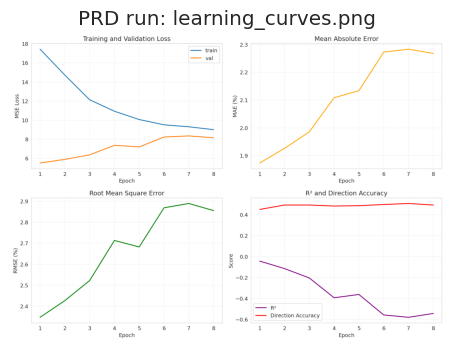

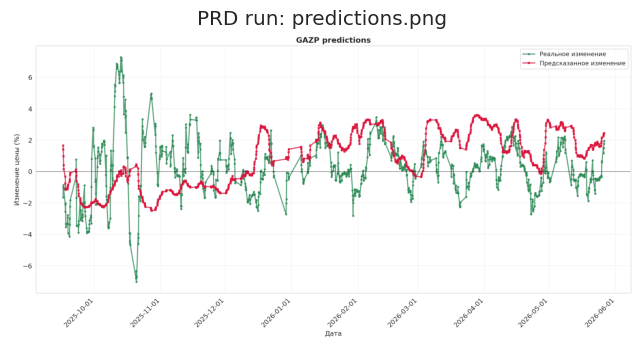

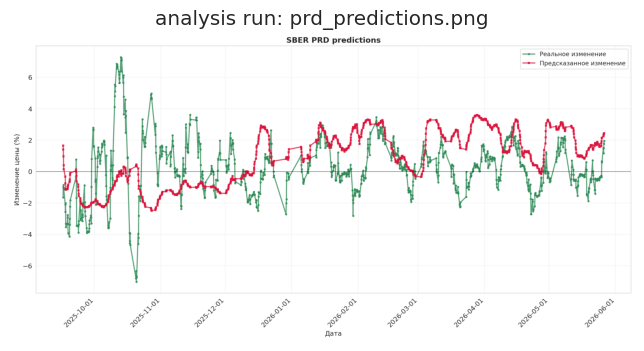

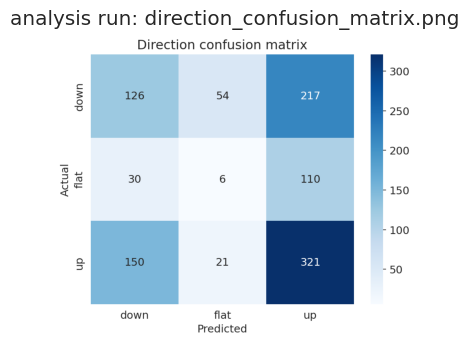

Loading data for ticker GAZP...
Running inference for GAZP using trained model from run fe645b594c794440a6d01ce05653b3f3...


Displaying results...
Metrics: {'mae': 2.470372438430786, 'rmse': np.float32(2.9350255), 'r2': -1.4911863803863525, 'direction_accuracy': np.float64(0.4599033816425121)}


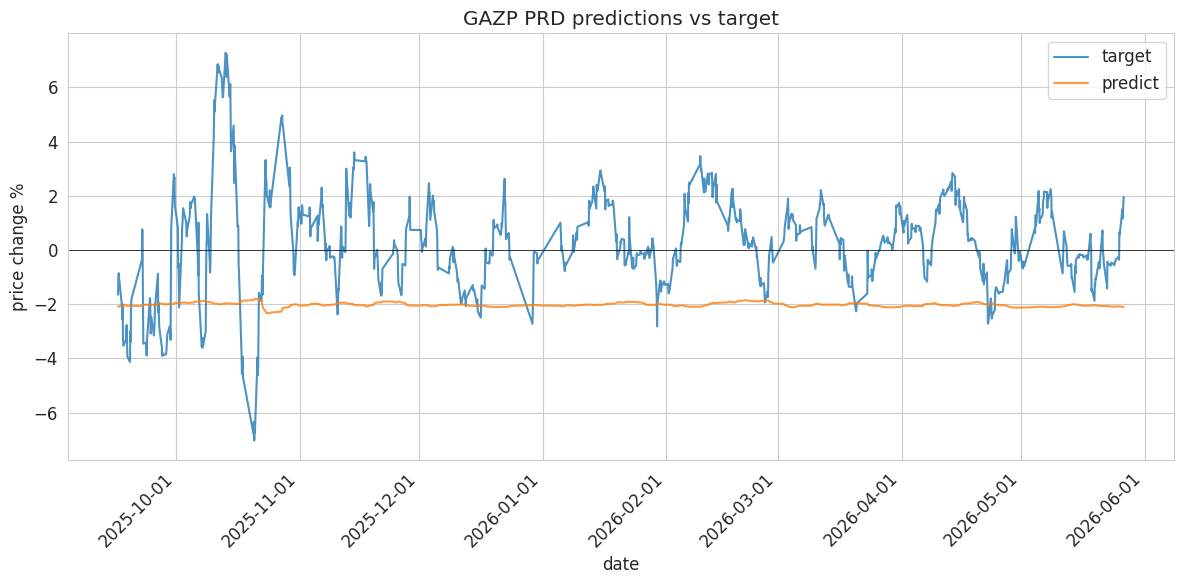

Analyzing results...


,Дата и время,Прогноз на дату и время,"Ожидаемое изменение, %","Фактическое изменение, %",Направление,Результат
0,2026-05-24 10:00,2026-05-31 10:00,-2.09,-0.56,падение,совпало
1,2026-05-24 12:00,2026-05-31 12:00,-2.09,-0.45,падение,совпало
2,2026-05-24 14:00,2026-05-31 14:00,-2.09,-0.45,падение,совпало
3,2026-05-24 16:00,2026-05-31 16:00,-2.09,-0.43,падение,совпало
4,2026-05-24 18:00,2026-05-31 18:00,-2.09,-0.35,падение,совпало
5,2026-05-25 10:00,2026-06-01 10:00,-2.08,-0.26,падение,совпало
6,2026-05-25 12:00,2026-06-01 12:00,-2.08,-0.28,падение,совпало
7,2026-05-25 14:00,2026-06-01 14:00,-2.08,-0.36,падение,совпало
8,2026-05-25 16:00,2026-06-01 16:00,-2.07,+0.66,падение,не совпало
9,2026-05-25 18:00,2026-06-01 18:00,-2.09,+0.58,падение,не совпало


In [13]:
run_demonstration('GAZP')

## LKOH

Ticker: LKOH
PRD run_id: 0b64304d3ff7495f983c5f9e9613246a


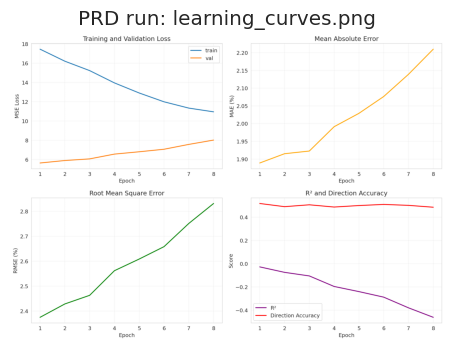

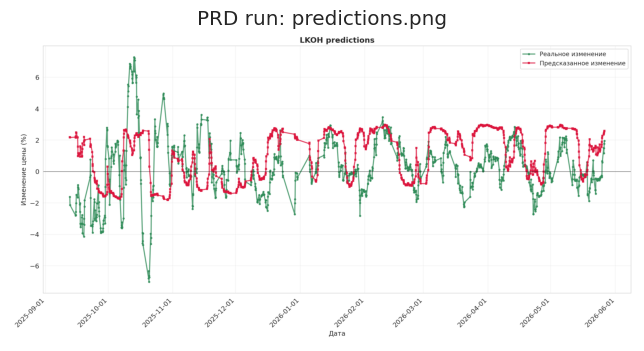

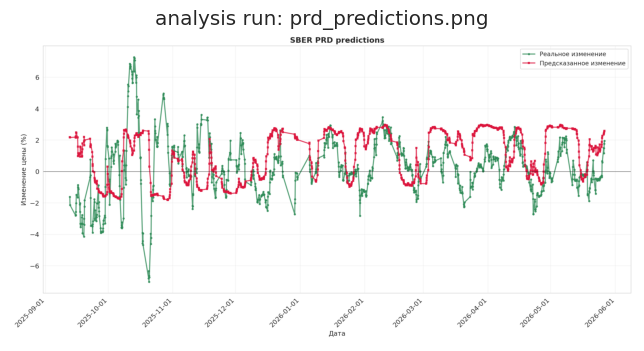

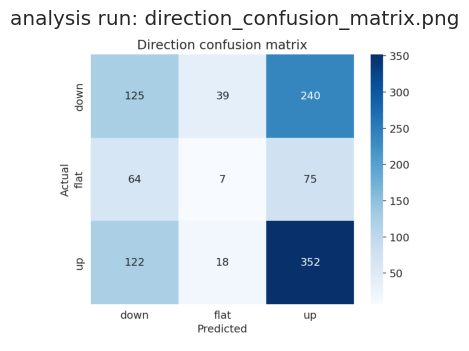

Loading data for ticker LKOH...
Running inference for LKOH using trained model from run 0b64304d3ff7495f983c5f9e9613246a...


Displaying results...
Metrics: {'mae': 3.2627675533294678, 'rmse': np.float32(3.6671834), 'r2': -2.8688580989837646, 'direction_accuracy': np.float64(0.5019193857965452)}


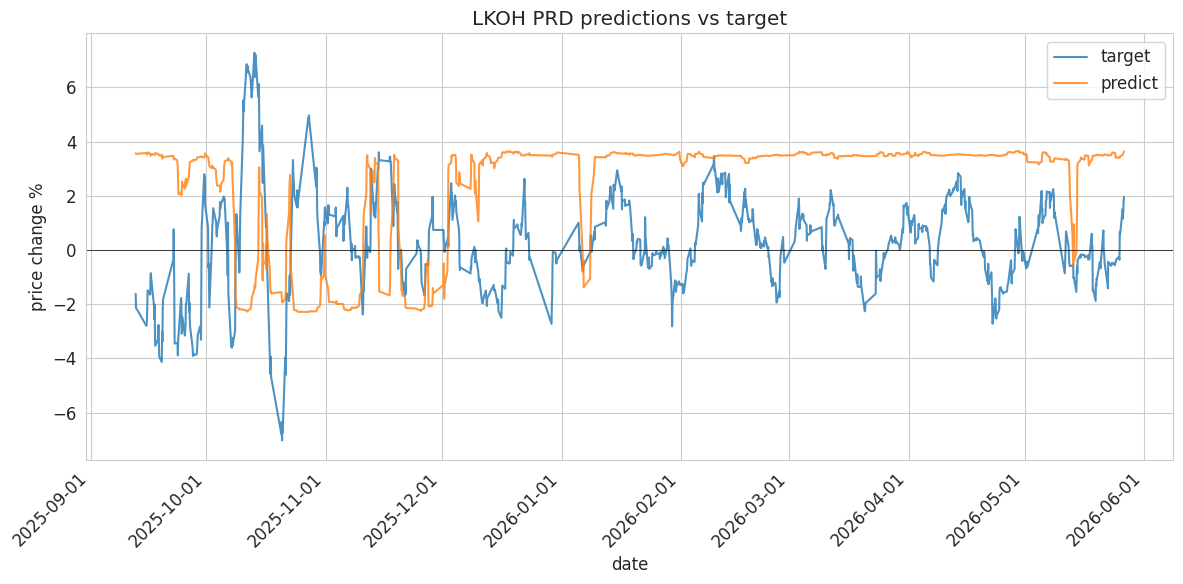

Analyzing results...


,Дата и время,Прогноз на дату и время,"Ожидаемое изменение, %","Фактическое изменение, %",Направление,Результат
0,2026-05-24 10:00,2026-05-31 10:00,+3.58,-0.56,рост,не совпало
1,2026-05-24 12:00,2026-05-31 12:00,+3.54,-0.45,рост,не совпало
2,2026-05-24 14:00,2026-05-31 14:00,+3.45,-0.45,рост,не совпало
3,2026-05-24 16:00,2026-05-31 16:00,+3.40,-0.43,рост,не совпало
4,2026-05-24 18:00,2026-05-31 18:00,+3.41,-0.35,рост,не совпало
5,2026-05-25 10:00,2026-06-01 10:00,+3.41,-0.26,рост,не совпало
6,2026-05-25 12:00,2026-06-01 12:00,+3.39,-0.28,рост,не совпало
7,2026-05-25 14:00,2026-06-01 14:00,+3.41,-0.36,рост,не совпало
8,2026-05-25 16:00,2026-06-01 16:00,+3.42,+0.66,рост,совпало
9,2026-05-25 18:00,2026-06-01 18:00,+3.46,+0.58,рост,совпало


In [14]:
run_demonstration('LKOH')

## ROSN

Ticker: ROSN
PRD run_id: 9aad2b7af49f42e586a82a16a5aa566c


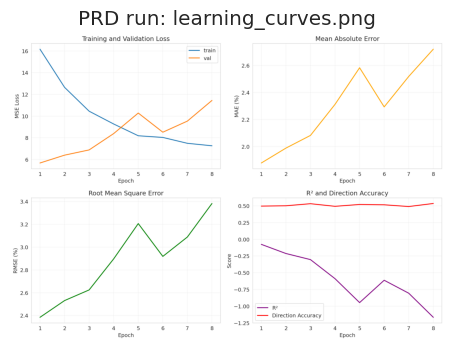

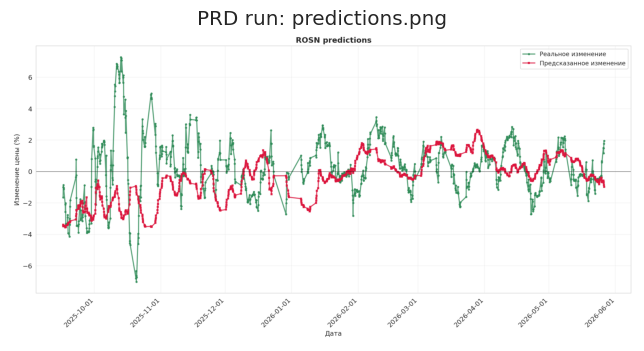

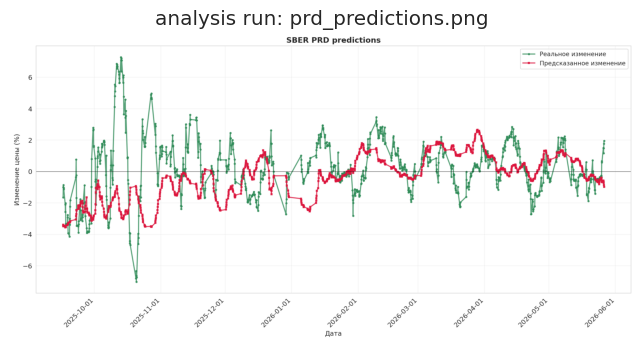

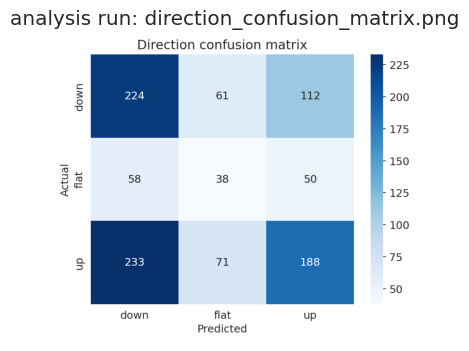

Loading data for ticker ROSN...
Running inference for ROSN using trained model from run 9aad2b7af49f42e586a82a16a5aa566c...


/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Displaying results...
Metrics: {'mae': 4.423995494842529, 'rmse': np.float32(4.8057194), 'r2': -5.678813457489014, 'direction_accuracy': np.float64(0.5285024154589372)}


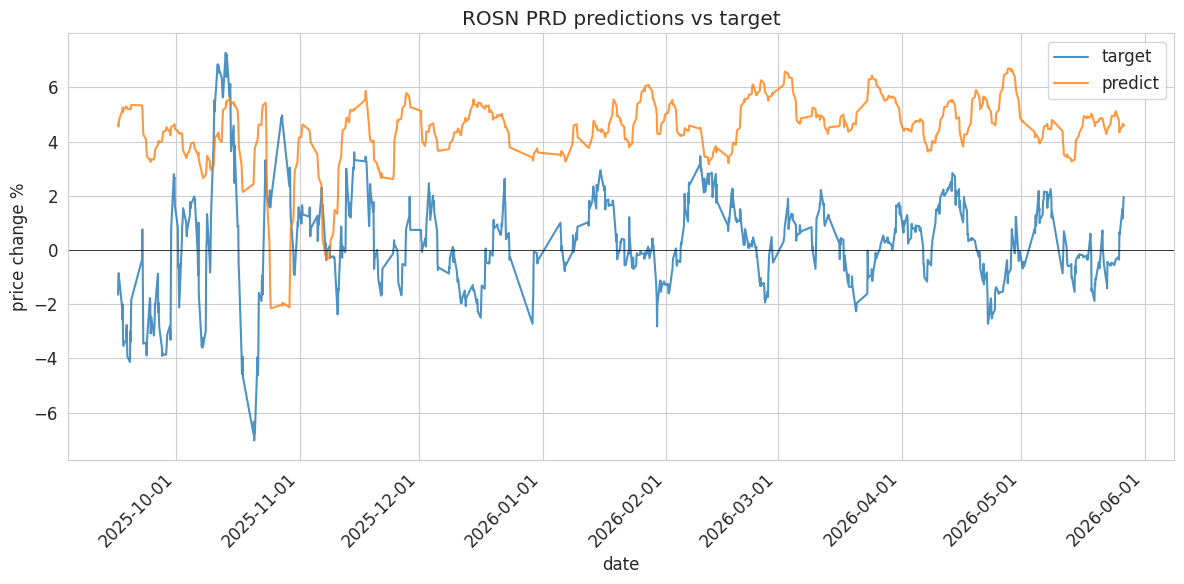

Analyzing results...


,Дата и время,Прогноз на дату и время,"Ожидаемое изменение, %","Фактическое изменение, %",Направление,Результат
0,2026-05-24 10:00,2026-05-31 10:00,+4.93,-0.56,рост,не совпало
1,2026-05-24 12:00,2026-05-31 12:00,+5.04,-0.45,рост,не совпало
2,2026-05-24 14:00,2026-05-31 14:00,+5.06,-0.45,рост,не совпало
3,2026-05-24 16:00,2026-05-31 16:00,+5.00,-0.43,рост,не совпало
4,2026-05-24 18:00,2026-05-31 18:00,+5.12,-0.35,рост,не совпало
5,2026-05-25 10:00,2026-06-01 10:00,+4.83,-0.26,рост,не совпало
6,2026-05-25 12:00,2026-06-01 12:00,+4.78,-0.28,рост,не совпало
7,2026-05-25 14:00,2026-06-01 14:00,+4.69,-0.36,рост,не совпало
8,2026-05-25 16:00,2026-06-01 16:00,+4.34,+0.66,рост,совпало
9,2026-05-25 18:00,2026-06-01 18:00,+4.42,+0.58,рост,совпало


In [15]:
run_demonstration('ROSN')